## Solving Schrödinger equation using finite difference scheme

In [1]:
LOAD_FROM_FILE = False

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import hermite,factorial
import torch
from param_search.A_train_ground_state import load_ground_state_pinn
from core.training import train_tise
from utils.utils import generate_input_data
from tise1d.tise1d import PotentialHarmonicOscillator, Loss_Orthogonality, Loss_PDE, ansatzfactor_HO_sym
from tise1d.analytic_ho import compare_analytic
from utils.cell_magic import skip_if
plt.style.use('./utils/_plot_style.mplstyle')

def psi_analytic(x, L = None, n=1):
    hbar = 1
    m = 1
    omega = 1
    return (1/(np.sqrt((2**n)*factorial(n))*np.pi**0.25))*np.exp(-x**2/2)*hermite(n)(x)

def solve_schrodinger(x,E,potential,L): 
    A = np.zeros((len(x) - 2,len(x) - 2))
    n = A.shape[0]
    delta_x = x[1] - x[0]
    A[0,0] = 1/delta_x**2 + potential(x[0] + delta_x)
    A[0,1] = -0.5/delta_x**2
    for i in range(1,n - 1): 
        A[i,i-1] = -0.5/delta_x**2
        A[i,i] = 1/delta_x**2 + potential(x[0] + delta_x*(i+1))
        A[i,i+1] = -0.5/delta_x**2
    A[n-1,n-2] = -0.5/delta_x**2
    A[n-1,n-1] = 1/delta_x**2 + potential(x[-1] - delta_x)

    eigval, psi = np.linalg.eigh(A)
    i = np.argmin(np.abs(eigval - E))
    psi_num = np.zeros_like(x)
    psi_num[1:n+1] = psi[:,i]
    return psi_num/np.sqrt(2*L*np.mean(psi_num**2))

def potential(x): 
    return 0.5*x**2


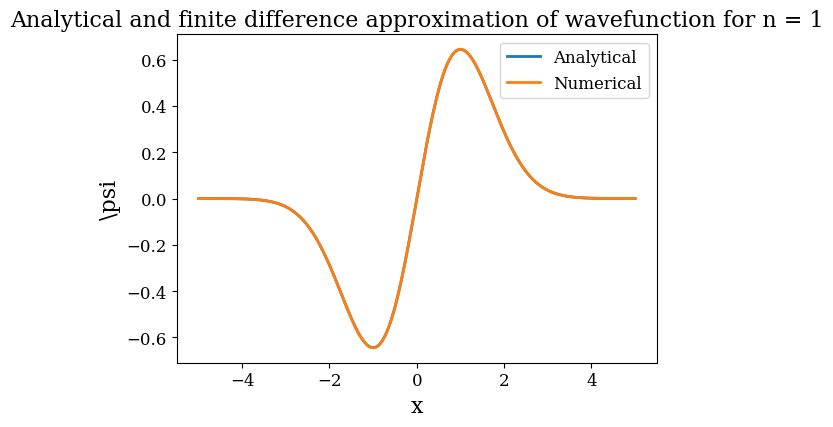

In [3]:
n = 1
L = 5

E_ana = n + 0.5

x = np.linspace(-L,L,401)

psi_ana = solve_schrodinger(x,E_ana,potential,L)

plt.plot(x,psi_analytic(x,n=n),label="Analytical")
plt.plot(x,psi_ana,label="Numerical")
plt.title(f"Analytical and finite difference approximation of wavefunction for n = {n}")
plt.xlabel("x")
plt.ylabel(r"\psi")
plt.legend()
plt.show()


In [4]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"

# Parameters used throughout the project
x_lim = (-L, L)
N_samples = 256

# Generate data points
torch.manual_seed(124)
x = generate_input_data(1024, x_lim, device)

In [5]:
pinn1 = load_ground_state_pinn(device)

### Plotting accuracy of numerical and NN solutions 

In [6]:
num = 21

n = np.logspace(1,3,num)

err = np.zeros((num,2))

# %%skip_if LOAD_FROM_FILE
torch.manual_seed(124)
for i in range(21): 
    x = torch.from_numpy(np.linspace(x_lim[0], x_lim[1], int(n[i]))).float().to(device).unsqueeze(-1)
    x_random = generate_input_data(int(n[i]), x_lim, device)

    pinn2 = train_tise(
        x_random,
        loss_func = Loss_PDE(PotentialHarmonicOscillator()) + 1.10*Loss_Orthogonality([pinn1]),
        x_lim=x_lim,
        lr = 7.37e-5,
        lr_energy=4.08e-2,
        E_init = 0.5,
        width=256,
        lambd = 1e-2,
        hidden_layers=4,
        ansatz_factor=ansatzfactor_HO_sym,
    )
    
    with torch.no_grad():
        psi_NN = pinn2(x).detach().cpu().numpy()

    psi_num = solve_schrodinger(x.numpy().squeeze(),E_ana,potential,L)

    # Flip sign if negative overlap
    overlap_num_NN = np.sum(psi_NN*psi_num)
    if overlap_num_NN < 0: 
        psi_NN = -psi_NN

    psi_exact = psi_analytic(x.numpy().squeeze(),n=1)
    overlap_num_exact = np.sum(psi_num*psi_exact)
    if overlap_num_exact < 0: 
        psi_NN = -psi_NN
        psi_num = -psi_num
    
    psi_NN_normalized = psi_NN/np.sqrt(L*np.mean(psi_NN**2))

    err[i,0] = np.mean((psi_NN_normalized - psi_exact)**2)
    err[i,1] = np.mean((psi_num - psi_exact)**2)
    print(".")


Epoch 100/3000. Best loss=3.896e-02. Current loss=4.964e-02. E=1.322732
Epoch 200/3000. Best loss=2.391e-03. Current loss=2.391e-03. E=1.378563
Epoch 300/3000. Best loss=1.599e-03. Current loss=1.599e-03. E=1.379420
Epoch 400/3000. Best loss=1.277e-03. Current loss=1.277e-03. E=1.381152
Epoch 500/3000. Best loss=1.197e-03. Current loss=1.197e-03. E=1.383097
Epoch 600/3000. Best loss=1.186e-03. Current loss=1.186e-03. E=1.385145
Epoch 700/3000. Best loss=1.183e-03. Current loss=1.183e-03. E=1.387242
Epoch 800/3000. Best loss=1.179e-03. Current loss=1.179e-03. E=1.389366
Epoch 900/3000. Best loss=1.173e-03. Current loss=1.173e-03. E=1.391506
Epoch 1000/3000. Best loss=1.167e-03. Current loss=1.167e-03. E=1.393653
Epoch 1100/3000. Best loss=1.159e-03. Current loss=1.163e-03. E=1.394754
Epoch 1200/3000. Best loss=1.158e-03. Current loss=1.158e-03. E=1.397091
Epoch 1300/3000. Best loss=1.158e-03. Current loss=1.178e-03. E=1.397519
Epoch 1400/3000. Best loss=1.151e-03. Current loss=1.152e-03

In [7]:
print(err)

[[2.90910175e-01 9.82356693e-03]
 [2.91693969e-01 3.12123613e-03]
 [2.93333284e-01 7.08327616e-04]
 [2.94736849e-01 2.61666561e-04]
 [2.95999983e-01 9.65255188e-05]
 [2.96774183e-01 4.85254078e-05]
 [2.97435918e-01 2.50542670e-05]
 [2.98000019e-01 1.31027870e-05]
 [2.98412688e-01 7.51230637e-06]
 [2.98734201e-01 4.49487488e-06]
 [2.99000009e-01 2.69130184e-06]
 [2.99199979e-01 1.67847467e-06]
 [2.99367103e-01 1.03317768e-06]
 [2.99497485e-01 6.44175856e-07]
 [2.99601624e-01 4.01931622e-07]
 [2.99683546e-01 2.52439314e-07]
 [2.99748762e-01 1.58707287e-07]
 [2.99800428e-01 9.99909798e-08]
 [2.99841260e-01 6.31441705e-08]
 [2.99874042e-01 3.99859106e-08]
 [2.99900009e-01 2.70389028e-08]]


In [8]:
filepath = "../data/numerical_NN_error.npy"

# Save data to file
np.save(filepath, err)

# Load data from file
if LOAD_FROM_FILE:
    err = np.load(filepath)

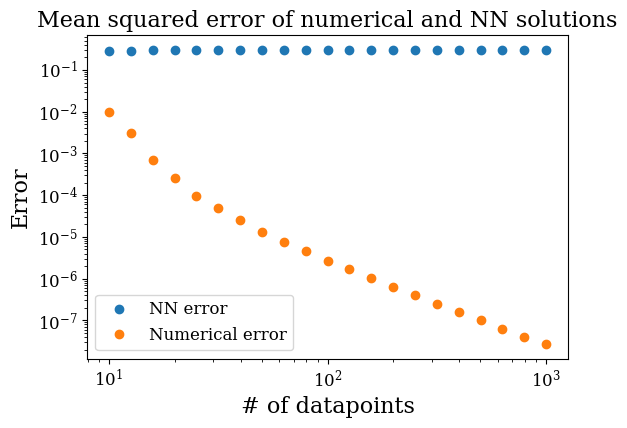

In [ ]:
plt.loglog(n,err[:,0],"--o",label="NN error")
plt.loglog(n,err[:,1],"--o",label="Numerical error")
plt.xlabel("# of datapoints")
plt.ylabel("Error")
plt.legend()
plt.title("Mean squared error of numerical and NN solutions")
plt.show()
    

## Attempting other excited energy eigenstates

In [10]:
pinn3 = train_tise(
    x,
    loss_func = Loss_PDE(PotentialHarmonicOscillator()) + 4.0*Loss_Orthogonality([pinn1,pinn2]),
    x_lim=x_lim,
    lr = 7.37e-5,
    lr_energy=4.08e-2,
    E_init = 1.5,
    width=256,
    lambd = 1e-2,
    hidden_layers=4,
    ansatz_factor=ansatzfactor_HO_sym,
)

Epoch 100/3000. Best loss=2.715e-01. Current loss=2.715e-01. E=2.644760
Epoch 200/3000. Best loss=1.182e-01. Current loss=1.182e-01. E=2.547382
Epoch 300/3000. Best loss=9.756e-02. Current loss=1.153e-01. E=2.527362
Epoch 400/3000. Best loss=8.374e-02. Current loss=1.224e-01. E=2.518686
Epoch 500/3000. Best loss=7.085e-02. Current loss=8.244e-02. E=2.539788
Epoch 600/3000. Best loss=5.958e-02. Current loss=6.954e-02. E=2.526509
Epoch 700/3000. Best loss=5.146e-02. Current loss=5.251e-02. E=2.518176
Epoch 800/3000. Best loss=4.495e-02. Current loss=5.130e-02. E=2.512676
Epoch 900/3000. Best loss=4.077e-02. Current loss=6.853e-02. E=2.489895
Epoch 1000/3000. Best loss=3.620e-02. Current loss=4.879e-02. E=2.507309
Epoch 1100/3000. Best loss=3.287e-02. Current loss=4.427e-02. E=2.528351
Epoch 1200/3000. Best loss=3.021e-02. Current loss=3.174e-02. E=2.507813
Epoch 1300/3000. Best loss=2.856e-02. Current loss=4.047e-02. E=2.485487
Epoch 1400/3000. Best loss=2.591e-02. Current loss=5.163e-02

In [11]:
x_test = torch.from_numpy(np.linspace(x_lim[0], x_lim[1], 1024)).float().to(device).unsqueeze(-1)

Predicted Energy: 2.507956, Exact Energy: 2.500000, Relative Error: 0.318222%


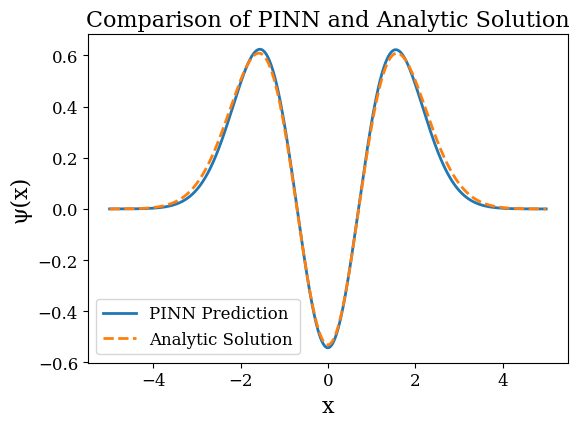

In [12]:
compare_analytic(x_test, x_lim,pinn3,n=2)

In [ ]:
pinn4 = train_tise(
x,
loss_func = Loss_PDE(PotentialHarmonicOscillator()) + 15.0*Loss_Orthogonality([pinn1,pinn2,pinn3]),
x_lim=x_lim,
lr = 7.37e-5,
lr_energy=4.08e-2,
E_init = 2.5,
width=256,
lambd = 1e-2,
hidden_layers=4,
ansatz_factor=ansatzfactor_HO_sym,
)

Epoch 100/3000. Best loss=3.296e+00. Current loss=4.386e+00. E=2.699644
Epoch 200/3000. Best loss=7.997e-01. Current loss=7.997e-01. E=3.841445
Epoch 300/3000. Best loss=6.507e-01. Current loss=6.608e-01. E=3.789517
Epoch 400/3000. Best loss=5.268e-01. Current loss=5.269e-01. E=3.721109
Epoch 500/3000. Best loss=4.297e-01. Current loss=4.299e-01. E=3.664435
Epoch 600/3000. Best loss=3.491e-01. Current loss=6.725e-01. E=3.651573
Epoch 700/3000. Best loss=3.137e-01. Current loss=5.669e-01. E=3.620936
Epoch 800/3000. Best loss=2.713e-01. Current loss=2.734e-01. E=3.596509
Epoch 900/3000. Best loss=2.577e-01. Current loss=3.221e-01. E=3.588081
Epoch 1000/3000. Best loss=2.401e-01. Current loss=8.846e-01. E=3.599906
Epoch 1100/3000. Best loss=2.377e-01. Current loss=3.789e-01. E=3.593557
Epoch 1200/3000. Best loss=2.241e-01. Current loss=2.274e-01. E=3.586775
Epoch 1300/3000. Best loss=2.176e-01. Current loss=4.229e-01. E=3.569073
Epoch 1400/3000. Best loss=2.129e-01. Current loss=2.264e-01

Predicted Energy: 3.551507, Exact Energy: 3.500000, Relative Error: 1.471642%


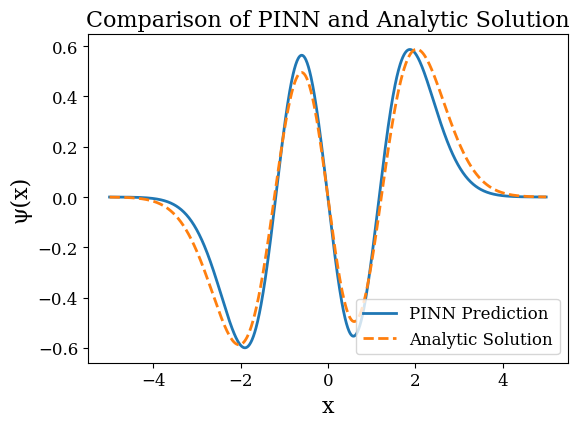

In [ ]:
compare_analytic(x_test, x_lim,pinn4,n=3)